# 05 — Semi-supervised: Mean Teacher (E5)

Mean Teacher (Tarvainen & Valpola, 2017) consistency regularization pipeline:
1. Mixed batches: labeled ISIC 2018 subset + unlabeled ISIC 2020 train
2. Student trained with supervised Focal loss (labeled) + MSE consistency (unlabeled)
3. Teacher = EMA of student weights, no gradient
4. Consistency weight ramps up sigmoidally over `rampup_epochs`

Evaluate on source test (ISIC 2018) + target test (ISIC 2020).
Compare AUC vs Label Budget against E2 baseline, E3 SSL, and E4 pseudo-labeling.


In [1]:
import os, sys, copy, json, torch, numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

from src.datasets import build_loaders
from src.models import build_backbone
from src.reporting import (
    evaluate_and_report, evaluate_on_csv, get_latest_run,
    collect_predictions, plot_training_history, collect_auc_vs_fraction, NumpyEncoder,
)
from src.trainers.mean_teacher import run_mean_teacher
from src.trainers.supervised import run_experiment
from src.utils import get_device, load_config, init_run_dir, cleanup
from src.metrics import compute_metrics, plot_auc_vs_labels, plot_confusion_matrix, plot_roc_curve
from data.scripts.make_label_subsets import FRACTIONS

ALL_FRACTIONS = FRACTIONS + [1.0]
print('ALL_FRACTIONS:', ALL_FRACTIONS)

ALL_FRACTIONS: [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]


In [2]:
config = load_config('configs/semisup.yaml')
config

{'experiment': {'name': 'mean_teacher_resnet18', 'seed': 42, 'device': 'auto'},
 'data': {'task': 'mean_teacher',
  'labeled_csv': 'data/processed/isic2018/train.csv',
  'unlabeled_csv': 'data/processed/isic2020/train.csv',
  'val_csv': 'data/processed/isic2018/val.csv',
  'img_size': 224,
  'batch_size': 32,
  'num_workers': 4,
  'unlabeled_ratio': 3.0,
  'use_weighted_sampler': True,
  'label_col': 'target'},
 'model': {'arch': 'resnet18', 'pretrained': True, 'num_classes': 1},
 'training': {'epochs': 50,
  'optimizer': 'adamw',
  'lr_backbone': 0.0001,
  'lr_head': 0.001,
  'weight_decay': 0.0001,
  'scheduler': 'cosine',
  'freeze_backbone_epochs': 5},
 'loss': {'type': 'focal', 'gamma': 2.0, 'alpha': 0.75},
 'semisup': {'ema_decay': 0.999,
  'consistency_weight': 10.0,
  'rampup_epochs': 10},
 'early_stopping': {'patience': 10, 'monitor': 'val_auc'},
 'logging': {'save_dir': 'results/runs'}}

## 1. Mean Teacher loop

For each fraction:
1. Configure labelled CSV = ISIC 2018 subset (or full if fraction=1.0)
2. Run `run_mean_teacher` on mixed batches (labelled + unlabelled ISIC 2020)
3. Save run in `results/runs/mean_teacher_ft_{fraction}/`

Skip if final run + checkpoints/best.pt exist and `RUN_MT=False`.
Use `copy.deepcopy(config)` to avoid mutation between iterations.


In [ ]:
RUN_MT = False  # True to force re-training

device = get_device(config['experiment'].get('device', 'auto'))
print(f'Device: {device}')

for fraction in ALL_FRACTIONS:
    exp_name = f'mean_teacher_ft_{fraction:.2f}'
    run_dir_ft = get_latest_run(exp_name)
    ft_complete = run_dir_ft is not None and (run_dir_ft / 'checkpoints/best.pt').exists()

    if ft_complete and not RUN_MT:
        print(f'[SKIP] {exp_name} — run already complete')
        cleanup()
        continue

    # Build config for this fraction
    mt_cfg = copy.deepcopy(config)
    if fraction >= 1.0:
        mt_cfg['data']['labeled_csv'] = 'data/processed/isic2018/train.csv'
    else:
        pct = int(round(fraction * 100))
        mt_cfg['data']['labeled_csv'] = f'data/processed/isic2018/subsets/train_{pct:02d}pct.csv'
    mt_cfg['data']['unlabeled_csv'] = 'data/processed/isic2020/train.csv'
    mt_cfg['data']['val_csv'] = 'data/processed/isic2018/val.csv'
    mt_cfg['experiment']['name'] = exp_name

    print(f"\n{'='*55}")
    print(f'Mean Teacher | fraction={fraction:.2f}')
    print(f"{'='*55}")

    result = run_mean_teacher(mt_cfg)
    print(f'[OK] {exp_name} | best_val_auc={result["best_val_auc"]:.4f}')

    # Free memory before next fraction
    del result, mt_cfg
    cleanup()

print('\nMean Teacher loop complete.')

Device: mps
[SKIP] mean_teacher_ft_0.01 — run gia completa
[SKIP] mean_teacher_ft_0.05 — run gia completa
[SKIP] mean_teacher_ft_0.10 — run gia completa
[SKIP] mean_teacher_ft_0.25 — run gia completa
[SKIP] mean_teacher_ft_0.50 — run gia completa
[SKIP] mean_teacher_ft_1.00 — run gia completa

Mean Teacher loop completato.


## 2. Evaluation on source (ISIC 2018) and target (ISIC 2020)

Load `best.pt` from each Mean Teacher run, evaluate on both test sets.
Save `test_metrics.json` (source) and `test_metrics_isic2020.json` (target).
Skip if files already exist and `RUN_EVAL=False`.

In [ ]:
RUN_EVAL = False

device = get_device(config['experiment'].get('device', 'auto'))

for fraction in ALL_FRACTIONS:
    exp_name = f'mean_teacher_ft_{fraction:.2f}'
    run_dir = get_latest_run(exp_name)
    if run_dir is None:
        print(f'[SKIP] {exp_name}: run not found')
        cleanup()
        continue
    ckpt_path = run_dir / 'checkpoints/best.pt'
    if not ckpt_path.exists():
        print(f'[SKIP] {exp_name}: best.pt missing')
        cleanup()
        continue

    src_metrics_path = run_dir / 'test_metrics.json'
    tgt_metrics_path = run_dir / 'test_metrics_isic2020.json'
    both_exist = src_metrics_path.exists() and tgt_metrics_path.exists()
    if both_exist and not RUN_EVAL:
        src_auc = json.load(open(src_metrics_path)).get('auc_roc', '?')
        tgt_auc = json.load(open(tgt_metrics_path)).get('auc_roc', '?')
        print(f'[SKIP] {exp_name}: src={src_auc:.4f} tgt={tgt_auc:.4f} (cached)')
        cleanup()
        continue

    # Evaluate source
    src_auc = evaluate_on_csv(
        run_dir, config,
        test_csv='data/processed/isic2018/test.csv',
        train_csv='data/processed/isic2018/train.csv',
        batch_size=64, device=device,
        metrics_name='test_metrics.json',
    )
    src_val = src_auc.get('auc_roc') if src_auc else None

    # Evaluate target
    tgt_auc = evaluate_on_csv(
        run_dir, config,
        test_csv='data/processed/isic2020/test.csv',
        train_csv='data/processed/isic2018/train.csv',
        batch_size=64, device=device,
        metrics_name='test_metrics_isic2020.json',
    )
    tgt_val = tgt_auc.get('auc_roc') if tgt_auc else None

    print(f'[DONE] {exp_name}: src={src_val:.4f} tgt={tgt_val:.4f}')
    cleanup()

print('\nEvaluation complete.')

[DONE] mean_teacher_ft_0.01: src=0.7400 tgt=0.5521
[DONE] mean_teacher_ft_0.05: src=0.8580 tgt=0.6839
[DONE] mean_teacher_ft_0.10: src=0.8560 tgt=0.6893
[DONE] mean_teacher_ft_0.25: src=0.8873 tgt=0.6699
[DONE] mean_teacher_ft_0.50: src=0.9012 tgt=0.6947
[DONE] mean_teacher_ft_1.00: src=0.9077 tgt=0.6918

Valutazione completata.


## 3. Collect AUC — Baseline, SSL, Pseudo-label, Mean Teacher

In [5]:
def _read_auc(run_dir, filename):
    p = run_dir / filename
    if p.exists():
        return json.load(open(p)).get('auc_roc')
    return None

# ── Mean Teacher ────────────────────────────────────────────────────────
aucs_2018_mt, aucs_2020_mt = {}, {}
for f in ALL_FRACTIONS:
    rd = get_latest_run(f'mean_teacher_ft_{f:.2f}')
    aucs_2018_mt[f] = _read_auc(rd, 'test_metrics.json') if rd else None
    aucs_2020_mt[f] = _read_auc(rd, 'test_metrics_isic2020.json') if rd else None

# ── Pseudo-label (from E4 runs) ─────────────────────────────────────────
aucs_2018_pseudo, aucs_2020_pseudo = {}, {}
for f in ALL_FRACTIONS:
    rd = get_latest_run(f'pseudo_label_ft_{f:.2f}')
    aucs_2018_pseudo[f] = _read_auc(rd, 'test_metrics.json') if rd else None
    aucs_2020_pseudo[f] = _read_auc(rd, 'test_metrics_isic2020.json') if rd else None

# ── Baseline (from E2 runs) ──────────────────────────────────────────────
aucs_2018_base, aucs_2020_base = {}, {}
for f in FRACTIONS:
    rd = get_latest_run(f'baseline_resnet18_{f:.2f}')
    aucs_2018_base[f] = _read_auc(rd, 'test_metrics.json') if rd else None
    aucs_2020_base[f] = _read_auc(rd, 'test_metrics_isic2020.json') if rd else None
rd_full = get_latest_run('baseline_resnet18_full')
aucs_2018_base[1.0] = _read_auc(rd_full, 'test_metrics.json') if rd_full else None
aucs_2020_base[1.0] = _read_auc(rd_full, 'test_metrics_isic2020.json') if rd_full else None

# ── SSL (from E3 runs) ───────────────────────────────────────────────────
aucs_2018_ssl, aucs_2020_ssl = {}, {}
for f in ALL_FRACTIONS:
    rd = get_latest_run(f'simclr_ft_{f:.2f}')
    aucs_2018_ssl[f] = _read_auc(rd, 'test_metrics.json') if rd else None
    aucs_2020_ssl[f] = _read_auc(rd, 'test_metrics_isic2020.json') if rd else None

print('MT     source:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2018_mt.items() if v})
print('MT     target:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2020_mt.items() if v})
print('Pseudo source:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2018_pseudo.items() if v})
print('Pseudo target:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2020_pseudo.items() if v})
print('Base  source:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2018_base.items() if v})
print('Base  target:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2020_base.items() if v})
print('SSL   source:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2018_ssl.items() if v})
print('SSL   target:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2020_ssl.items() if v})

MT     source: {'1%': 0.74, '5%': 0.858, '10%': 0.856, '25%': 0.8873, '50%': 0.9012, '100%': 0.9077}
MT     target: {'1%': 0.5521, '5%': 0.6839, '10%': 0.6893, '25%': 0.6699, '50%': 0.6947, '100%': 0.6918}
Pseudo source: {'10%': 0.866, '25%': 0.8711, '50%': 0.9063, '100%': 0.9244}
Pseudo target: {'10%': 0.6725, '25%': 0.6255, '50%': 0.6445, '100%': 0.6473}
Base  source: {'1%': 0.8138, '5%': 0.8629, '10%': 0.8631, '25%': 0.8679, '50%': 0.9065, '100%': 0.9181}
Base  target: {'1%': 0.6619, '5%': 0.7118, '10%': 0.6853, '25%': 0.6294, '50%': 0.6353, '100%': 0.6975}
SSL   source: {'1%': 0.8451, '5%': 0.873, '10%': 0.8699, '25%': 0.8836, '50%': 0.909, '100%': 0.934}
SSL   target: {'1%': 0.7984, '5%': 0.6736, '10%': 0.6559, '25%': 0.6144, '50%': 0.6817, '100%': 0.6939}


## 4. Plot AUC vs Label Budget — Baseline vs SSL vs Pseudo-label vs Mean Teacher

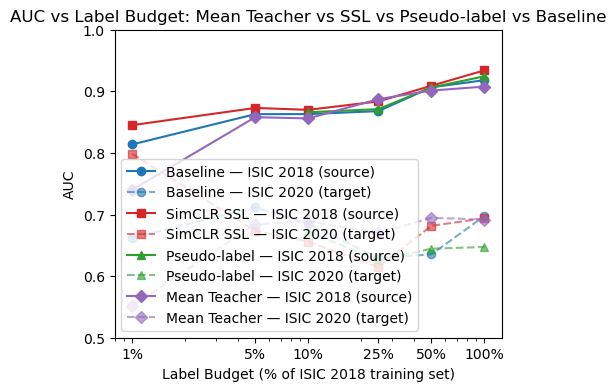

Figura salvata in results/figures/auc_vs_labels_mt.png


In [ ]:
results = {
    'Baseline — ISIC 2018 (source)':         {f: v for f, v in aucs_2018_base.items() if v is not None},
    'Baseline — ISIC 2020 (target)':         {f: v for f, v in aucs_2020_base.items() if v is not None},
    'SimCLR SSL — ISIC 2018 (source)':       {f: v for f, v in aucs_2018_ssl.items() if v is not None},
    'SimCLR SSL — ISIC 2020 (target)':       {f: v for f, v in aucs_2020_ssl.items() if v is not None},
    'Pseudo-label — ISIC 2018 (source)':     {f: v for f, v in aucs_2018_pseudo.items() if v is not None},
    'Pseudo-label — ISIC 2020 (target)':     {f: v for f, v in aucs_2020_pseudo.items() if v is not None},
    'Mean Teacher — ISIC 2018 (source)':     {f: v for f, v in aucs_2018_mt.items() if v is not None},
    'Mean Teacher — ISIC 2020 (target)':     {f: v for f, v in aucs_2020_mt.items() if v is not None},
}
style_map = {
    'Baseline — ISIC 2018 (source)':         {'color': 'tab:blue',   'linestyle': '-',  'marker': 'o'},
    'Baseline — ISIC 2020 (target)':         {'color': 'tab:blue',   'linestyle': '--', 'marker': 'o', 'alpha': 0.6},
    'SimCLR SSL — ISIC 2018 (source)':       {'color': 'tab:red',    'linestyle': '-',  'marker': 's'},
    'SimCLR SSL — ISIC 2020 (target)':       {'color': 'tab:red',    'linestyle': '--', 'marker': 's', 'alpha': 0.6},
    'Pseudo-label — ISIC 2018 (source)':     {'color': 'tab:green',  'linestyle': '-',  'marker': '^'},
    'Pseudo-label — ISIC 2020 (target)':     {'color': 'tab:green',  'linestyle': '--', 'marker': '^', 'alpha': 0.6},
    'Mean Teacher — ISIC 2018 (source)':     {'color': 'tab:purple', 'linestyle': '-',  'marker': 'D'},
    'Mean Teacher — ISIC 2020 (target)':     {'color': 'tab:purple', 'linestyle': '--', 'marker': 'D', 'alpha': 0.6},
}
out_path = 'results/figures/auc_vs_labels_mt.png'
fig = plot_auc_vs_labels(
    results,
    save_path=out_path,
    x_scale='log',
    x_as_percent=True,
    title='AUC vs Label Budget: Mean Teacher vs SSL vs Pseudo-label vs Baseline',
    ylim=(0.5, 1.0),
    style_map=style_map,
)
plt.show()
print(f'Figure saved in {out_path}')

## 5. Summary table

In [ ]:
def _s(d, f):
    v = d.get(f)
    return round(v, 4) if v is not None else float('nan')

rows = []
for f in ALL_FRACTIONS:
    rows.append({
        'fraction':          f'{f*100:.0f}%',
        'base_src_auc':      _s(aucs_2018_base, f),
        'base_tgt_auc':      _s(aucs_2020_base, f),
        'ssl_src_auc':       _s(aucs_2018_ssl, f),
        'ssl_tgt_auc':       _s(aucs_2020_ssl, f),
        'pseudo_src_auc':    _s(aucs_2018_pseudo, f),
        'pseudo_tgt_auc':    _s(aucs_2020_pseudo, f),
        'mt_src_auc':        _s(aucs_2018_mt, f),
        'mt_tgt_auc':        _s(aucs_2020_mt, f),
        'delta_mt_vs_base_src': round(_s(aucs_2018_mt, f) - _s(aucs_2018_base, f), 4),
        'delta_mt_vs_base_tgt': round(_s(aucs_2020_mt, f) - _s(aucs_2020_base, f), 4),
        'delta_mt_vs_pseudo_tgt': round(_s(aucs_2020_mt, f) - _s(aucs_2020_pseudo, f), 4),
    })

df = pd.DataFrame(rows).set_index('fraction')
print(df.to_string())
Path('results/metrics').mkdir(parents=True, exist_ok=True)
df.to_csv('results/metrics/mt_vs_baseline.csv')
print('\nSaved in results/metrics/mt_vs_baseline.csv')

          base_src_auc  base_tgt_auc  ssl_src_auc  ssl_tgt_auc  pseudo_src_auc  pseudo_tgt_auc  mt_src_auc  mt_tgt_auc  delta_mt_vs_base_src  delta_mt_vs_base_tgt  delta_mt_vs_pseudo_tgt
fraction                                                                                                                                                                                  
1%              0.8138        0.6619       0.8451       0.7984             NaN             NaN      0.7400      0.5521               -0.0738               -0.1098                     NaN
5%              0.8629        0.7118       0.8730       0.6736             NaN             NaN      0.8580      0.6839               -0.0049               -0.0279                     NaN
10%             0.8631        0.6853       0.8699       0.6559          0.8660          0.6725      0.8560      0.6893               -0.0071                0.0040                  0.0168
25%             0.8679        0.6294       0.8836       0.6144   

## 6. Diagnostic — training history and training metrics

In [ ]:
# 6a — Training history for each Mean Teacher run
for fraction in ALL_FRACTIONS:
    exp_name = f'mean_teacher_ft_{fraction:.2f}'
    rd = get_latest_run(exp_name)
    if rd is None:
        print(f'[SKIP] {exp_name}: run not found')
        continue
    save_path = str(rd / 'figures/training_history.png')
    plot_training_history(rd, save_path=save_path)
    print(f'fraction={fraction:.2f} | saved in {save_path}')

fraction=0.01 | salvato in results/runs/mean_teacher_ft_0.01/20260603_131816/figures/training_history.png
fraction=0.05 | salvato in results/runs/mean_teacher_ft_0.05/20260603_140016/figures/training_history.png
fraction=0.10 | salvato in results/runs/mean_teacher_ft_0.10/20260603_154337/figures/training_history.png
fraction=0.25 | salvato in results/runs/mean_teacher_ft_0.25/20260603_171436/figures/training_history.png
fraction=0.50 | salvato in results/runs/mean_teacher_ft_0.50/20260603_201601/figures/training_history.png
fraction=1.00 | salvato in results/runs/mean_teacher_ft_1.00/20260604_014122/figures/training_history.png


In [ ]:
# 6b — Consistency weight and split loss per run
print(f"{'Fraction':>10} | {'Epochs':>7} | {'Best val_auc':>13} | {'Final sup_loss':>15} | {'Final cons_loss':>16} | {'Max cons_w':>11}")
print('-' * 80)

for fraction in ALL_FRACTIONS:
    rd = get_latest_run(f'mean_teacher_ft_{fraction:.2f}')
    if rd is None or not (rd / 'metrics.jsonl').exists():
        continue
    lines = (rd / 'metrics.jsonl').read_text().strip().split('\n')
    entries = [json.loads(l) for l in lines if l.strip()]
    if not entries:
        continue
    n_epochs = len(entries)
    best_val = max(e.get('val_auc', 0) for e in entries)
    last = entries[-1]
    sup_loss = last.get('train_sup_loss', float('nan'))
    cons_loss = last.get('train_cons_loss', float('nan'))
    max_cw = max(e.get('cons_weight', 0) for e in entries)
    print(f'{fraction*100:>9.0f}% | {n_epochs:>7} | {best_val:>13.4f} | {sup_loss:>15.6f} | {cons_loss:>16.6f} | {max_cw:>11.4f}')

  Fraction |  Epochs |  Best val_auc |  Final sup_loss |  Final cons_loss |  Max cons_w
--------------------------------------------------------------------------------
        1% |      41 |        0.6877 |        0.049939 |         0.001256 |     10.0000
        5% |      50 |        0.8343 |        0.033012 |         0.001123 |     10.0000
       10% |      33 |        0.8703 |        0.031001 |         0.001000 |     10.0000
       25% |      41 |        0.8747 |        0.020083 |         0.002951 |     10.0000
       50% |      43 |        0.8995 |        0.017922 |         0.010651 |     10.0000
      100% |      29 |        0.9071 |        0.022141 |         0.013722 |     10.0000


In [ ]:
# 6c — Max val_auc per run (baseline vs pseudo-label vs MT)
print(f"{'Fraction':>10} | {'Base val_auc_max':>16} | {'Pseudo val_auc_max':>19} | {'MT val_auc_max':>17}")
print('-' * 68)

for f in ALL_FRACTIONS:
    def _max_val_auc(exp_name):
        rd = get_latest_run(exp_name)
        if rd is None or not (rd / 'metrics.jsonl').exists():
            return None
        lines = (rd / 'metrics.jsonl').read_text().strip().split('\n')
        aucs = [json.loads(l).get('val_auc') for l in lines if l.strip()]
        aucs = [a for a in aucs if a is not None]
        return round(max(aucs), 4) if aucs else None

    if f < 1.0:
        b_val = _max_val_auc(f'baseline_resnet18_{f:.2f}')
    else:
        b_val = _max_val_auc('baseline_resnet18_full')
    p_val = _max_val_auc(f'pseudo_label_ft_{f:.2f}')
    m_val = _max_val_auc(f'mean_teacher_ft_{f:.2f}')

    b_str = f'{b_val:.4f}' if b_val else 'N/A'
    p_str = f'{p_val:.4f}' if p_val else 'N/A'
    m_str = f'{m_val:.4f}' if m_val else 'N/A'
    print(f"{f*100:>9.0f}% | {b_str:>16} | {p_str:>19} | {m_str:>17}")

  Fraction | Base val_auc_max |  Pseudo val_auc_max |    MT val_auc_max
--------------------------------------------------------------------
        1% |           0.7799 |                 N/A |            0.6877
        5% |           0.8355 |                 N/A |            0.8343
       10% |           0.8709 |              0.8643 |            0.8703
       25% |           0.8808 |              0.8781 |            0.8747
       50% |           0.9137 |              0.9174 |            0.8995
      100% |           0.9279 |              0.9433 |            0.9071
